<a href="https://colab.research.google.com/github/ruyoliv/DataCom/blob/main/qam_simples.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📡 MODULAÇÃO QAM
### Explicação preparada com auxílio do LLM Claude.

---

## O que é QAM em uma frase?

> **QAM é uma forma de enviar vários bits de uma vez, escolhendo um ponto num mapa de sinais.**

---

## A Analogia do Ponteiro

Imagine um ponteiro de relógio. Ele tem:
- Um **ângulo** (para onde aponta) → isso é a **fase**
- Um **comprimento** (quão longo é) → isso é a **amplitude**

Cada posição única do ponteiro = um **símbolo** = um grupo de bits.

| Técnica | O que muda | Bits por símbolo |
|---------|-----------|------------------|
| ASK | só amplitude | 1 |
| PSK | só fase | 1–2 |
| **QAM** | **amplitude E fase juntos** | **2, 4, 6, 8...** |

```
Sinal QAM:  s(t)  =  I · cos(2π·fc·t)  −  Q · sin(2π·fc·t)
                      ↑                     ↑
                  componente I          componente Q
                  (in-phase)            (quadrature, 90° defasado)
```

In [ ]:
# ── Importações ────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch

plt.rcParams.update({
    'figure.facecolor': '#f5f7fa',
    'axes.facecolor':   '#ffffff',
    'axes.grid':        True,
    'grid.alpha':       0.25,
    'grid.linestyle':   '--',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.size':        12,
})
np.random.seed(42)

# ── Constantes de cor (usadas em todo o notebook) ─────────────
C = ['#e63946', '#457b9d', '#2a9d8f', '#e9c46a',
     '#f4a261', '#264653', '#a8dadc', '#6d6875',
     '#b5838d', '#e76f51', '#52b788', '#4361ee',
     '#7209b7', '#f72585', '#3a86ff', '#06d6a0']

print('✅ Tudo carregado!')

✅ Tudo carregado!


---
## 1️⃣ O Mapa de Símbolos (Constelação)

No **16-QAM** existem **16 pontos** dispostos numa grade 4×4.
Cada ponto representa **4 bits**. O transmissor apenas aponta para o ponto certo.

As **linhas tracejadas vermelhas** são os **limites de decisão**:
o receptor olha para onde o sinal chegou e decide em qual região ele está.

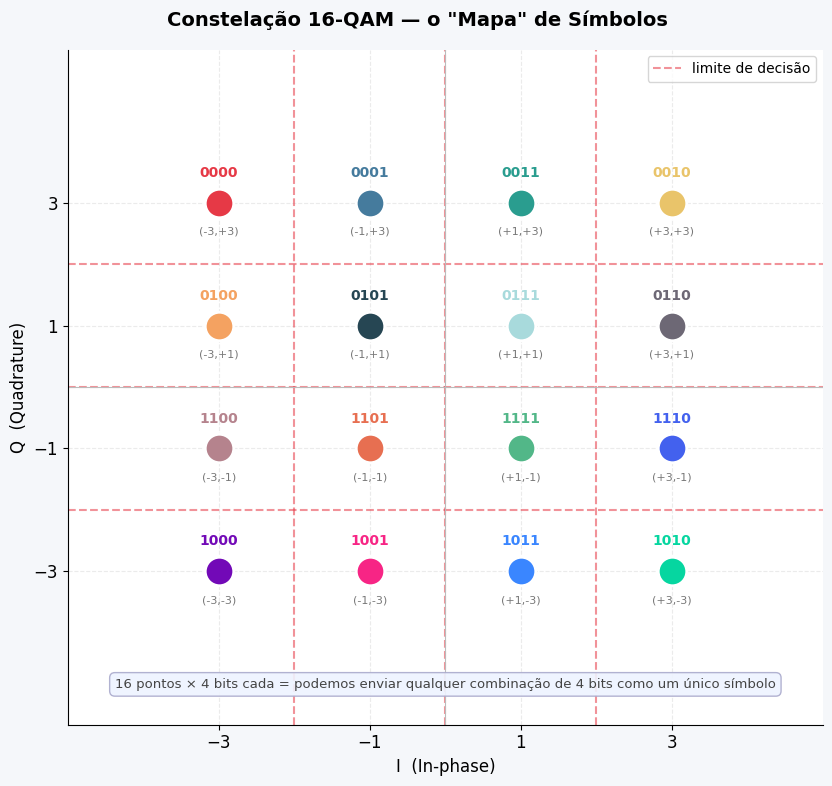

✅ Mapa de símbolos pronto!


In [ ]:
# ── Gera constelação 16-QAM ───────────────────────────────────
levels = [-3, -1, 1, 3]
gray   = ['00', '01', '11', '10']   # código Gray

symbols = {}   # bits_str → (I, Q)
for qi, q in enumerate(reversed(levels)):
    for ii, iv in enumerate(levels):
        bits = gray[qi] + gray[ii]
        symbols[bits] = (float(iv), float(q))

IQ_array = np.array(list(symbols.values()))   # shape (16, 2)

# ── Figura ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8.5, 8))
fig.suptitle('Constelação 16-QAM — o "Mapa" de Símbolos',
             fontsize=14, fontweight='bold')

for k, (bits, (iv, q)) in enumerate(symbols.items()):
    ax.scatter(iv, q, s=420, color=C[k], zorder=5,
               edgecolors='white', linewidths=2)
    # rótulo: bits em cima, coordenadas embaixo
    ax.text(iv,  q + 0.42, bits, ha='center', fontsize=10,
            fontweight='bold', color=C[k])
    ax.text(iv,  q - 0.52, f'({iv:+.0f},{q:+.0f})', ha='center',
            fontsize=8, color='#777')

# limites de decisão
for v in [-2, 0, 2]:
    ax.axhline(v, color='#e63946', lw=1.5, linestyle='--', alpha=0.55,
               label='limite de decisão' if v == -2 else '')
    ax.axvline(v, color='#e63946', lw=1.5, linestyle='--', alpha=0.55)

ax.axhline(0, color='#bbb', lw=0.8)
ax.axvline(0, color='#bbb', lw=0.8)
ax.set_xlim(-5, 5); ax.set_ylim(-5.5, 5.5)
ax.set_xticks(levels); ax.set_yticks(levels)
ax.set_xlabel('I  (In-phase)', fontsize=12)
ax.set_ylabel('Q  (Quadrature)', fontsize=12)
ax.legend(fontsize=10)

# caixa explicativa
ax.text(0, -4.9,
        '16 pontos × 4 bits cada = podemos enviar qualquer combinação de 4 bits como um único símbolo',
        ha='center', fontsize=9.5, color='#444',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#eef3ff',
                  edgecolor='#aac', alpha=0.9))

plt.tight_layout()
plt.savefig('01_constellation.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Mapa de símbolos pronto!')

---
## 2️⃣ Transmitindo uma Sequência de Bits

Vamos transmitir: **`0010 1101 0111 1000`** (16 bits = 4 símbolos)

**O que o transmissor faz:**
1. Pega 4 bits → acha o ponto (I, Q) no mapa
2. Gera um pedaço de onda com aquela amplitude e fase
3. Repete para o próximo grupo de 4 bits

Bits enviados: 0010110101111000

Grupo    → ponto (I, Q)     amplitude    fase
-------------------------------------------------------
0010       (+3, +3)             4.24        45.0°
1101       (-1, -1)             1.41        -135.0°
0111       (+1, +1)             1.41        45.0°
1000       (-3, -3)             4.24        -135.0°


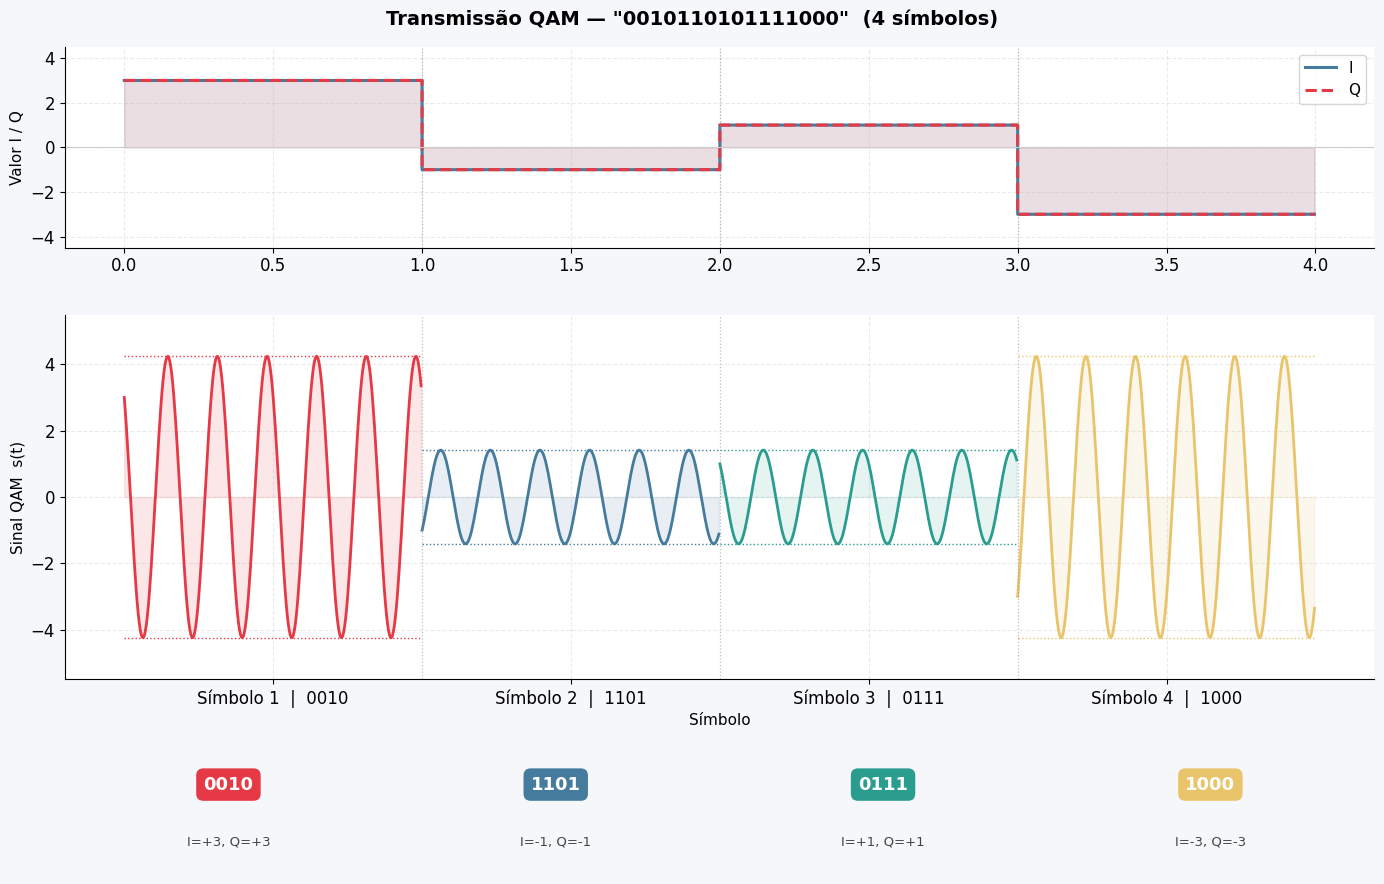

✅ Transmissão gerada!


In [ ]:
# ── Parâmetros de transmissão ─────────────────────────────────
fc   = 6.0    # frequência da portadora (Hz)
sps  = 300    # amostras por símbolo
t_s  = np.linspace(0, 1, sps, endpoint=False)

bits_str = '0010110101111000'
#bits_str = '0010110101111010'
groups   = [bits_str[i*4:(i+1)*4] for i in range(4)]
IQ_tx    = [symbols[g] for g in groups]

# ── Codificação ───────────────────────────────────────────────
print('Bits enviados:', bits_str)
print()
print(f'{"Grupo":<8} {"→ ponto (I, Q)":<18} {"amplitude":<12} fase')
print('-' * 55)
for g, (iv, q) in zip(groups, IQ_tx):
    amp  = np.sqrt(iv**2 + q**2)
    fase = np.degrees(np.arctan2(q, iv))
    print(f'{g:<8}   ({iv:+.0f}, {q:+.0f})             {amp:.2f}        {fase:.1f}°')

# ── Gera sinal ────────────────────────────────────────────────
parts = [iv*np.cos(2*np.pi*fc*t_s) - q*np.sin(2*np.pi*fc*t_s)
         for iv, q in IQ_tx]
full_sig = np.concatenate(parts)
t_full   = np.linspace(0, 4, 4*sps, endpoint=False)
SYM_C    = [C[0], C[1], C[2], C[3]]

# ── Figura: 3 painéis ─────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 9),
                          gridspec_kw={'height_ratios': [1.1, 2, 0.7]})
fig.suptitle(f'Transmissão QAM — "{bits_str}"  (4 símbolos)',
             fontsize=14, fontweight='bold')

# Painel 1 — I e Q por símbolo
I_step = np.repeat([v[0] for v in IQ_tx], sps).astype(float)
Q_step = np.repeat([v[1] for v in IQ_tx], sps).astype(float)
axes[0].step(t_full, I_step, color='#457b9d', lw=2.2, where='post', label='I')
axes[0].step(t_full, Q_step, color='#e63946', lw=2.2, where='post',
             linestyle='--', label='Q')
axes[0].fill_between(t_full, I_step, step='post', alpha=0.1, color='#457b9d')
axes[0].fill_between(t_full, Q_step, step='post', alpha=0.1, color='#e63946')
axes[0].axhline(0, color='#ccc', lw=0.8)
axes[0].set_ylim(-4.5, 4.5)
axes[0].set_ylabel('Valor I / Q', fontsize=11)
axes[0].legend(fontsize=11, loc='upper right')

# Painel 2 — sinal QAM colorido por símbolo
for k, (part, (iv, q), col) in enumerate(zip(parts, IQ_tx, SYM_C)):
    t_k = t_full[k*sps:(k+1)*sps]
    axes[1].plot(t_k, part, color=col, lw=2)
    axes[1].fill_between(t_k, part, 0, alpha=0.12, color=col)
    env = np.sqrt(iv**2 + q**2)
    axes[1].plot(t_k,  env*np.ones(sps), color=col, lw=1, linestyle=':')
    axes[1].plot(t_k, -env*np.ones(sps), color=col, lw=1, linestyle=':')
axes[1].set_ylim(-5.5, 5.5)
axes[1].set_ylabel('Sinal QAM  s(t)', fontsize=11)

# Painel 3 — etiquetas
axes[2].axis('off')
axes[2].set_xlim(0, 4); axes[2].set_ylim(0, 1)
for k, (g, (iv, q), col) in enumerate(zip(groups, IQ_tx, SYM_C)):
    axes[2].text(k+0.5, 0.70, g, ha='center', va='center',
                 fontsize=13, fontweight='bold', color='white',
                 bbox=dict(boxstyle='round,pad=0.4', facecolor=col, edgecolor='none'))
    axes[2].text(k+0.5, 0.22, f'I={iv:+.0f}, Q={q:+.0f}', ha='center',
                 fontsize=9.5, color='#444')

# separadores
for i in range(1, 4):
    for ax in axes[:2]:
        ax.axvline(i, color='gray', lw=0.9, linestyle=':', alpha=0.5)

axes[1].set_xlabel('Símbolo', fontsize=11)
axes[1].set_xticks(np.arange(0.5, 4))
axes[1].set_xticklabels([f'Símbolo {k+1}  |  {g}' for k, g in enumerate(groups)])

plt.tight_layout()
plt.savefig('02_transmission.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Transmissão gerada!')

---
## 3️⃣ O Caminho no Mapa

Outra forma de ver a mesma transmissão: o transmissor **pula de ponto em ponto** no mapa.
O receptor precisa descobrir em qual ponto cada símbolo recebido está.

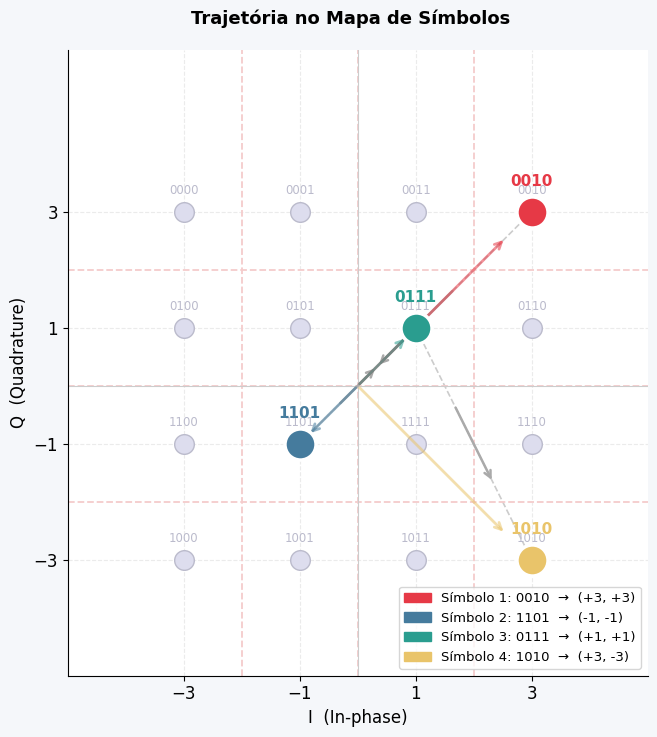

✅ Trajetória gerada!


In [ ]:
fig, ax = plt.subplots(figsize=(8, 7.5))
fig.suptitle('Trajetória no Mapa de Símbolos', fontsize=13, fontweight='bold')

# todos os pontos em cinza
for bits_k, (iv, q) in symbols.items():
    ax.scatter(iv, q, s=200, color='#dde', zorder=2,
               edgecolors='#bbc', linewidths=1)
    ax.text(iv, q+0.3, bits_k, ha='center', fontsize=8.5, color='#bbc')

# limites de decisão
for v in [-2, 0, 2]:
    ax.axhline(v, color='#f5cccc', lw=1.3, linestyle='--')
    ax.axvline(v, color='#f5cccc', lw=1.3, linestyle='--')
ax.axhline(0, color='#ccc', lw=0.8)
ax.axvline(0, color='#ccc', lw=0.8)

# setas de trajetória entre símbolos consecutivos
for k in range(len(IQ_tx)-1):
    x0, y0 = IQ_tx[k]
    x1, y1 = IQ_tx[k+1]
    ax.annotate('', xy=((x0+2*x1)/3, (y0+2*y1)/3),
                xytext=((2*x0+x1)/3, (2*y0+y1)/3),
                arrowprops=dict(arrowstyle='->', color='#aaa', lw=1.8))
    ax.plot([x0, x1], [y0, y1], color='#ccc', lw=1.2, linestyle='--', zorder=1)

# pontos transmitidos em destaque
for k, (g, (iv, q), col) in enumerate(zip(groups, IQ_tx, SYM_C)):
    ax.annotate('', xy=(iv*0.85, q*0.85), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color=col, lw=2, alpha=0.55))
    ax.scatter(iv, q, s=500, color=col, zorder=6,
               edgecolors='white', linewidths=2.5)
    ax.text(iv, q+0.45, g, ha='center', fontsize=11,
            fontweight='bold', color=col)
    ax.text(iv, q, str(k+1), ha='center', va='center',
            fontsize=9, color='white', fontweight='bold')

ax.set_xlim(-5, 5); ax.set_ylim(-5, 5.8)
ax.set_xticks(levels); ax.set_yticks(levels)
ax.set_xlabel('I  (In-phase)', fontsize=12)
ax.set_ylabel('Q  (Quadrature)', fontsize=12)
ax.set_aspect('equal')

handles = [mpatches.Patch(color=SYM_C[k],
           label=f'Símbolo {k+1}: {groups[k]}  →  ({IQ_tx[k][0]:+.0f}, {IQ_tx[k][1]:+.0f})')
           for k in range(4)]
ax.legend(handles=handles, fontsize=9.5, loc='lower right')

plt.tight_layout()
plt.savefig('03_path.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Trajetória gerada!')

---
## 4️⃣ O Problema do Ruído

O canal real **não é perfeito** — ele adiciona ruído ao sinal.

```
Transmissor            Canal                Receptor
    ●  (I,Q)  ──────── + ruído ──────────▶  ●' (I+ε, Q+δ)
               ruído empurra o ponto!
```

- Se o ponto chegou **dentro da região correta** → decodificação **correta** ✅  
- Se o ruído foi grande demais e o ponto **cruzou o limite** → **erro** ❌

O **SNR** (relação sinal/ruído) controla isso:
- SNR alto → ruído pequeno → poucos erros  
- SNR baixo → ruído grande → muitos erros

/tmp/ipykernel_531/3412687796.py:72: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout(pad=2.5)
/tmp/ipykernel_531/3412687796.py:72: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout(pad=2.5)
/tmp/ipykernel_531/3412687796.py:73: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('04_noise.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_531/3412687796.py:73: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('04_noise.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
 

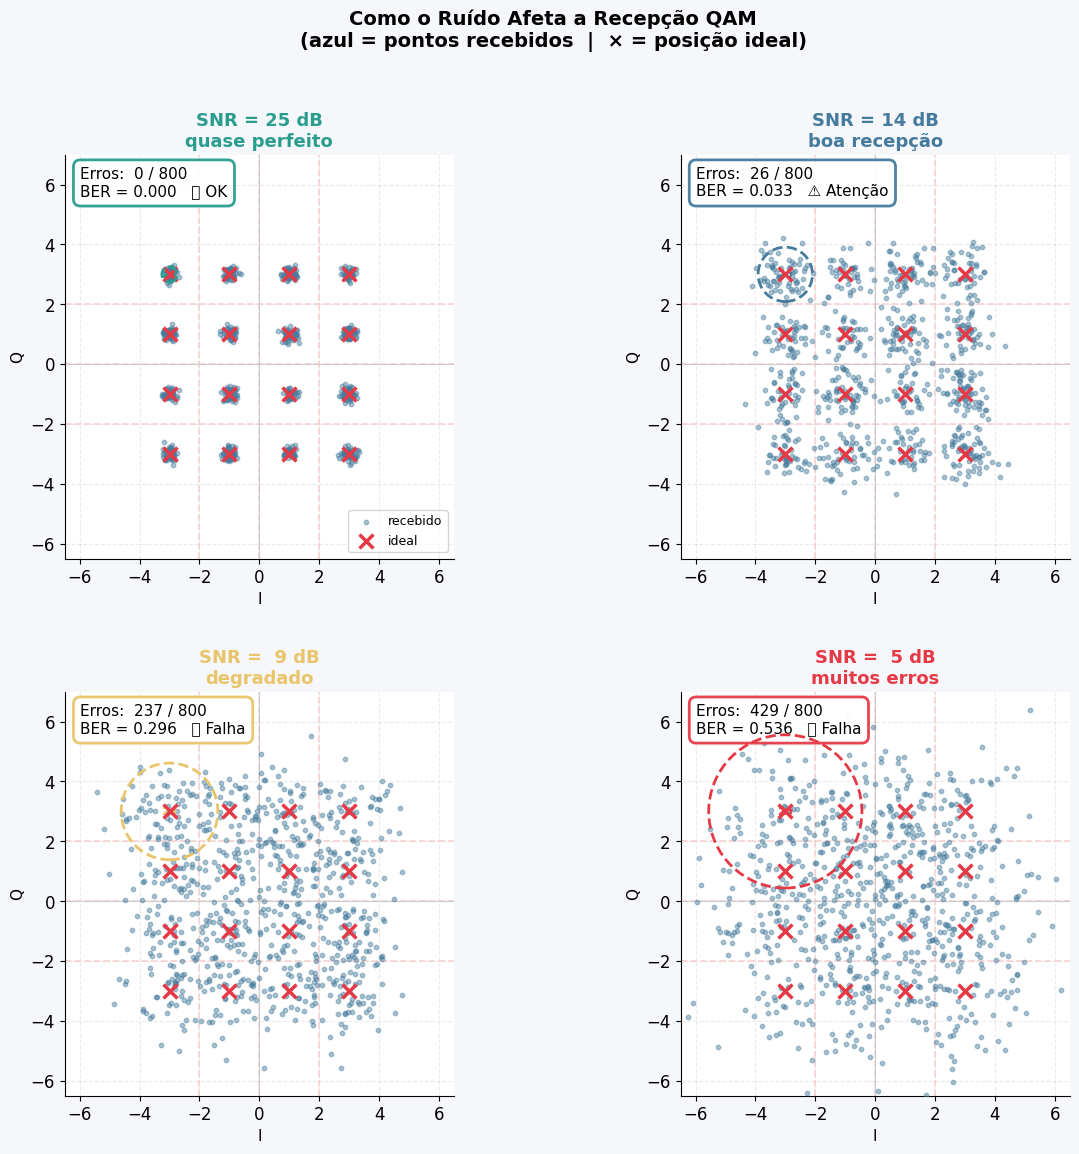

✅ Efeito do ruído gerado!


In [ ]:
# ── Simula recepção com ruído ──────────────────────────────────
n_test    = 800
snr_list  = [25, 14, 9, 5]
labels_sn = ['SNR = 25 dB\nquase perfeito',
             'SNR = 14 dB\nboa recepção',
             'SNR =  9 dB\ndegradado',
             'SNR =  5 dB\nmuitos erros']
colors_sn = ['#2a9d8f', '#457b9d', '#e9c46a', '#e63946']

tx_idx    = np.random.randint(0, 16, n_test)
I_tx_arr  = IQ_array[tx_idx, 0]
Q_tx_arr  = IQ_array[tx_idx, 1]
sig_pwr   = np.mean(I_tx_arr**2 + Q_tx_arr**2)

fig, axes = plt.subplots(2, 2, figsize=(13, 12))
fig.suptitle('Como o Ruído Afeta a Recepção QAM\n'
             '(azul = pontos recebidos  |  × = posição ideal)',
             fontsize=14, fontweight='bold')

for ax, snr_db, lbl, col in zip(axes.flatten(), snr_list, labels_sn, colors_sn):

    snr_lin   = 10**(snr_db/10)
    noise_std = np.sqrt(sig_pwr / (2 * snr_lin))

    I_rx = I_tx_arr + np.random.normal(0, noise_std, n_test)
    Q_rx = Q_tx_arr + np.random.normal(0, noise_std, n_test)

    # decisão: ponto mais próximo
    rx_idx  = np.array([np.argmin((IQ_array[:,0]-ir)**2 + (IQ_array[:,1]-qr)**2)
                         for ir, qr in zip(I_rx, Q_rx)])
    n_err   = int(np.sum(tx_idx != rx_idx))
    ber     = n_err / n_test
    status  = '✅ OK' if ber < 0.01 else ('⚠️ Atenção' if ber < 0.1 else '❌ Falha')

    # pontos recebidos
    ax.scatter(I_rx, Q_rx, s=10, alpha=0.45, color='#457b9d', zorder=3,
               label='recebido')

    # pontos ideais
    ax.scatter(IQ_array[:,0], IQ_array[:,1], s=100, color='#e63946',
               zorder=6, marker='x', linewidths=2.5, label='ideal')

    # círculo de "raio de ruído" em torno de um ponto exemplo
    circ = plt.Circle((-3, 3), noise_std*2, color=col,
                      fill=False, linestyle='--', lw=2, zorder=7)
    ax.add_patch(circ)
    ax.text(-3, 3, '2σ', ha='center', va='center',
            fontsize=8, color=col, fontweight='bold')

    # limites de decisão
    for v in [-2, 0, 2]:
        ax.axhline(v, color='#f5cccc', lw=1.3, linestyle='--', alpha=0.8)
        ax.axvline(v, color='#f5cccc', lw=1.3, linestyle='--', alpha=0.8)
    ax.axhline(0, color='#ccc', lw=0.8)
    ax.axvline(0, color='#ccc', lw=0.8)

    ax.set_xlim(-6.5, 6.5); ax.set_ylim(-6.5, 7)
    ax.set_aspect('equal')
    ax.set_xlabel('I', fontsize=11); ax.set_ylabel('Q', fontsize=11)
    ax.set_title(lbl, fontsize=13, fontweight='bold', color=col)

    if ax == axes[0][0]:
        ax.legend(fontsize=9, loc='lower right')

    # caixa de estatísticas
    ax.text(0.04, 0.97,
            f'Erros:  {n_err} / {n_test}\nBER = {ber:.3f}   {status}',
            transform=ax.transAxes, fontsize=11, va='top',
            bbox=dict(boxstyle='round,pad=0.45', facecolor='white',
                      edgecolor=col, lw=2, alpha=0.95))

plt.tight_layout(pad=2.5)
plt.savefig('04_noise.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Efeito do ruído gerado!')

---
## 5️⃣ O Limite do Ruído: Curva BER × SNR

Este é o gráfico mais importante de um sistema QAM:
mostra **quantos erros** esperamos para cada nível de SNR.

**Como ler:**
- Quanto mais à **esquerda** a curva cai, **melhor** (precisa de menos SNR)
- Quanto **mais alto** o M (número de símbolos), mais à **direita** a curva fica
- A linha tracejada mostra BER = 1% — limite mínimo aceitável

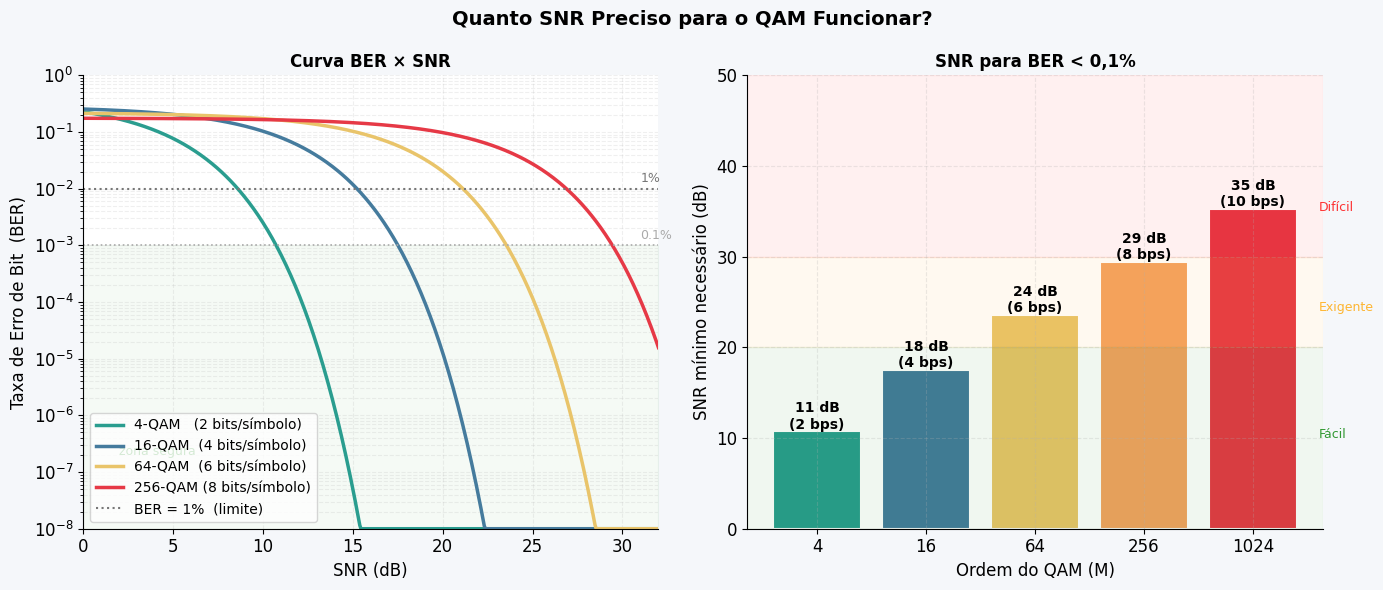

✅ Curvas BER geradas!


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Quanto SNR Preciso para o QAM Funcionar?',
             fontsize=14, fontweight='bold')

orders = [
    (4,   '#2a9d8f', '4-QAM   (2 bits/símbolo)'),
    (16,  '#457b9d', '16-QAM  (4 bits/símbolo)'),
    (64,  '#e9c46a', '64-QAM  (6 bits/símbolo)'),
    (256, '#e63946', '256-QAM (8 bits/símbolo)'),
]

snr_range = np.linspace(0, 32, 500)

# ─── Curvas BER ───────────────────────────────────────────────
ax = axes[0]
for M, color, label in orders:
    sl  = 10**(snr_range/10)
    ber = 3/(2*np.log2(M)) * (1 - 1/np.sqrt(M)) * np.exp(-3*sl / (2*(M-1)))
    ber = np.clip(ber, 1e-8, 1)
    ax.semilogy(snr_range, ber, color=color, lw=2.5, label=label)

ax.axhline(0.01,  color='#777', lw=1.5, linestyle=':', label='BER = 1%  (limite)')
ax.axhline(0.001, color='#aaa', lw=1.2, linestyle=':')
ax.text(31, 0.013,  '1%',   fontsize=9, color='#777')
ax.text(31, 0.0013, '0.1%', fontsize=9, color='#aaa')

# zona segura
ax.fill_betweenx([1e-8, 0.001], 0, 32, alpha=0.04, color='green')
ax.text(2, 2e-7, 'zona segura', fontsize=9, color='green', alpha=0.8)

ax.set_xlabel('SNR (dB)', fontsize=12)
ax.set_ylabel('Taxa de Erro de Bit  (BER)', fontsize=12)
ax.set_title('Curva BER × SNR', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.set_xlim(0, 32); ax.set_ylim(1e-8, 1)
ax.grid(True, which='both', alpha=0.2)

# ─── Barras: SNR mínimo por ordem ────────────────────────────
ax2 = axes[1]
M_list = [4, 16, 64, 256, 1024]
bar_colors = ['#2a9d8f','#457b9d','#e9c46a','#f4a261','#e63946']
snr_min = []
for M in M_list:
    snr_db_t = np.linspace(0, 45, 8000)
    sl_t = 10**(snr_db_t/10)
    ber_t = 3/(2*np.log2(M))*(1-1/np.sqrt(M))*np.exp(-3*sl_t/(2*(M-1)))
    i = np.argmin(np.abs(ber_t - 1e-3))
    snr_min.append(snr_db_t[i])

bars = ax2.bar([str(M) for M in M_list], snr_min,
               color=bar_colors, edgecolor='white', lw=1.5)
for bar, s, M in zip(bars, snr_min, M_list):
    bps = int(np.log2(M))
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
             f'{s:.0f} dB\n({bps} bps)',
             ha='center', fontsize=10, fontweight='bold')

# zonas
ax2.axhspan(0,  20, alpha=0.06, color='green')
ax2.axhspan(20, 30, alpha=0.06, color='orange')
ax2.axhspan(30, 50, alpha=0.06, color='red')
ax2.text(4.6, 10,  'Fácil',    fontsize=9, color='green',  alpha=0.8)
ax2.text(4.6, 24,  'Exigente', fontsize=9, color='orange', alpha=0.8)
ax2.text(4.6, 35,  'Difícil',  fontsize=9, color='red',    alpha=0.8)

ax2.set_xlabel('Ordem do QAM (M)', fontsize=12)
ax2.set_ylabel('SNR mínimo necessário (dB)', fontsize=12)
ax2.set_title('SNR para BER < 0,1%', fontsize=12, fontweight='bold')
ax2.set_ylim(0, 50)

plt.tight_layout()
plt.savefig('05_ber.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Curvas BER geradas!')

---
## ✅ Resumo em 4 Frases

| # | Conceito | Resumo |
|---|----------|--------|
| 1 | **O mapa** | Cada ponto no mapa I×Q representa um grupo de bits |
| 2 | **Transmissão** | O transmissor gera uma onda com amplitude e fase do ponto escolhido |
| 3 | **Recepção** | O receptor mede I e Q e decide o ponto mais próximo |
| 4 | **Ruído** | Empurra o ponto para fora do lugar — se cruzar o limite, ocorre erro |

---

### Trade-off fundamental:

$$\boxed{\text{mais bits por símbolo}\quad\Longleftrightarrow\quad\text{mais SNR necessário}}$$

### Como o Wi-Fi e o 5G lidam com isso?
Usam **QAM adaptativo**: medem o SNR do canal e trocam de ordem automaticamente:

```
Perto do roteador  →  1024-QAM  (máxima velocidade)
Distância média    →   256-QAM
Longe, sinal fraco →    16-QAM  (pelo menos funciona!)
```